## Feature Selection

Prepare data.

Add and visualize holidays and seasons.

For feature selection, compute:
- F-Statistic
- Mutual Information
- Feature Importance with ExtraTreesClassifier
- Correlation Matrix (heatmap)

In [1]:
import pandas as pd
import numpy as np
import holidays
from sklearn.feature_selection import f_classif, mutual_info_classif, SelectKBest
from scipy.stats import f
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')
data.head()

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,...,tourism,totalSnow_cm,windspeedKmph,tempC,visibility,precipMM,name_day,count_bus_multimodality,geohash_origin,holiday
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
2,BIT,3s3792,2021-12-31 22:40:52+00:00,2021-12-31 22:51:29+00:00,10.600000,46.048926,11.129365,46.064934,11.123120,2120.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pvvq,False
3,BIT,3s1958,2021-12-31 22:26:34+00:00,2021-12-31 22:28:57+00:00,2.366667,46.067012,11.124158,46.069095,11.125884,460.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
4,BIT,3s3792,2021-12-31 22:12:54+00:00,2021-12-31 22:20:07+00:00,7.216667,46.060690,11.121921,46.048941,11.129363,1870.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj1,False


In [3]:
data.geohash_origin.nunique() # trips origin are distributed in a total of 40 cells

40

In [4]:
data.columns

Index(['operator', 'trip_vehicle_id', 'trip_start', 'trip_end',
       'trip_duration_break_excluded', 'trip_origin_latitude',
       'trip_origin_longitude', 'trip_destination_latitude',
       'trip_destination_longitude', 'trip_length', 'unique_id', 'leisure',
       'public_services', 'building', 'education', 'food', 'transport',
       'finantial', 'healthcare', 'office', 'shop', 'tourism', 'totalSnow_cm',
       'windspeedKmph', 'tempC', 'visibility', 'precipMM', 'name_day',
       'count_bus_multimodality', 'geohash_origin', 'holiday'],
      dtype='object')

In [5]:
data['date'] = data.trip_start.dt.date
data['hour'] = data.trip_start.dt.hour

In [6]:
df = data.groupby(['date','hour']).aggregate({'name_day':lambda x:x.to_list()[0], 'leisure':['sum'], 'public_services':['sum'], 'building':['sum'], 
            'education':['sum'], 'food':['sum'], 'transport':['sum'], 'finantial':['sum'], 'healthcare':['sum'], 'office':['sum'], 'shop':['sum'], 'tourism':['sum'], 
            'totalSnow_cm':['mean'], 'FeelsLikeC':['mean'], 'windspeedKmph':['mean'], 'tempC':['mean'], 'visibility':['mean'], 'precipMM':['mean'], 'count_bus_multimodality':['mean'], 
            'unique_id':['count']}).reset_index()
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)
df

,date,hour,name_day,leisure,public_services,building,education,food,transport,finantial,...,office,shop,tourism,totalSnow_cm,windspeedKmph,tempC,visibility,precipMM,count_bus_multimodality,trips_count
0,2020-11-30,15,monday,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,9.0,10.0,0.0,0.0,2
1,2020-11-30,16,monday,0.0,0.0,2.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,8.0,10.0,0.0,0.0,1
2,2020-11-30,17,monday,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,7.0,10.0,0.0,0.0,3
3,2020-11-30,18,monday,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,2.0,6.0,10.0,0.0,0.0,2
4,2020-11-30,19,monday,0.0,0.0,0.0,0.0,1.0,2.0,0.0,...,1.0,5.0,0.0,0.0,1.0,6.0,10.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8629,2022-05-04,19,wednesday,0.0,0.0,0.0,0.0,9.0,20.0,1.0,...,1.0,3.0,0.0,0.0,5.0,7.0,9.0,0.1,0.0,16
8630,2022-05-04,20,wednesday,0.0,0.0,1.0,6.0,4.0,3.0,0.0,...,0.0,5.0,0.0,0.0,4.0,5.0,10.0,0.0,0.0,12
8631,2022-05-04,21,wednesday,1.0,1.0,0.0,1.0,1.0,13.0,0.0,...,0.0,6.0,0.0,0.0,3.0,4.0,10.0,0.0,0.0,15
8632,2022-05-04,22,wednesday,1.0,2.0,0.0,6.0,4.0,19.0,1.0,...,1.0,4.0,1.0,0.0,3.0,6.0,10.0,0.0,0.0,15


In [7]:
df.trips_count.max(), df.trips_count.mean(), df.trips_count.median()

(47, 9.821982858466528, 9.0)

In [8]:
# convert weekday name to number
d = {'monday':1, 'tuesday':2, 'wednesday':3, 'thursday':4, 'friday':5, 'saturday':6, 'sunday':7}
for i in range(len(df)):
    df.at[i, 'name_day'] = d[df.at[i, 'name_day']]

In [9]:
df.describe()

,hour,leisure,public_services,building,education,food,transport,finantial,healthcare,office,shop,tourism,totalSnow_cm,windspeedKmph,tempC,visibility,precipMM,count_bus_multimodality,trips_count
count,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000,8634.000000
mean,12.480195,0.462126,0.234538,0.989344,0.832175,1.859625,9.693885,0.370975,0.211489,0.539611,2.998494,0.397846,0.061721,4.465254,7.645703,9.184271,0.135175,0.024013,9.821983
std,5.499841,1.036355,0.540287,1.778966,1.707833,2.306771,8.150657,0.921245,0.568673,1.084785,3.225115,1.051351,0.809109,2.531215,7.926288,1.898069,0.634449,0.102261,6.583569
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.000000,0.000000,0.000000,0.000000,1.000000
25%,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,10.000000,0.000000,0.000000,4.000000
50%,13.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,4.000000,7.000000,10.000000,0.000000,0.000000,9.000000
75%,17.000000,1.000000,0.000000,2.000000,1.000000,3.000000,14.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,6.000000,13.000000,10.000000,0.000000,0.000000,14.000000
max,23.000000,17.000000,5.000000,14.000000,21.000000,23.000000,61.000000,10.000000,7.000000,15.000000,31.000000,21.000000,21.100000,19.000000,32.000000,10.000000,19.500000,2.000000,47.000000


In [10]:
df['holiday'] = [df.at[i, 'date'] in holidays.Italy() for i in range(len(df))]

<AxesSubplot:xlabel='hour', ylabel='trips_count'>

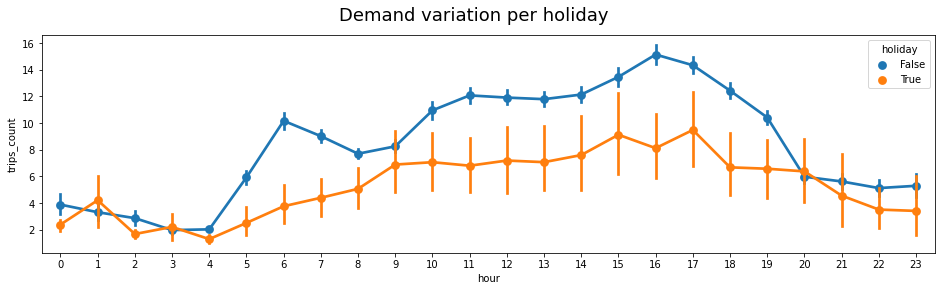

In [18]:
fig,ax = plt.subplots(figsize=(16,4))
fig.suptitle("Demand variation per holiday", fontsize=18)
sns.pointplot(data=df[["hour", "trips_count", "holiday"]],
              x="hour", y = "trips_count", hue="holiday", ax=ax)

In [12]:
def season(date):
    year = date.year
    if date >= dt.date(year, 3, 21) and date <= dt.date(year, 6, 20):
        return 'spring'
    elif date >= dt.date(year, 6, 21) and date <= dt.date(year, 9, 22):
        return 'summer'
    elif date >= dt.date(year, 9, 23) and date <= dt.date(year, 12, 21):
        return 'autumn'
    else:
        return 'winter'


df['season'] = [season(df.at[i, 'date']) for i in range(len(df))]

<AxesSubplot:xlabel='hour', ylabel='trips_count'>

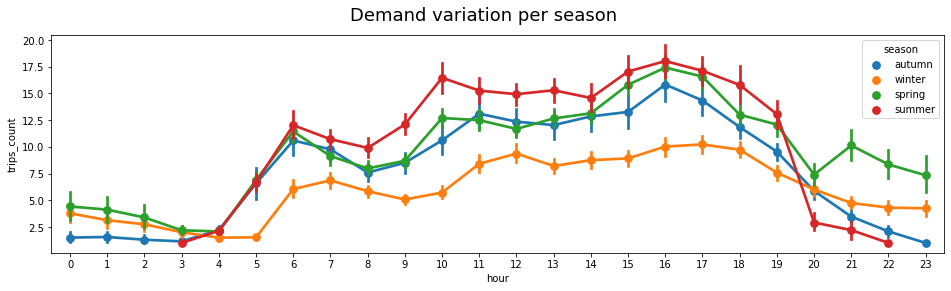

In [17]:
fig,ax = plt.subplots(figsize=(16,4))
fig.suptitle("Demand variation per season", fontsize=18)
sns.pointplot(data=df[["hour", "trips_count", "season"]],
              x="hour", y = "trips_count", hue="season", ax=ax)

[Text(0.5, 1.0, 'Seasonal distribution of trips count')]

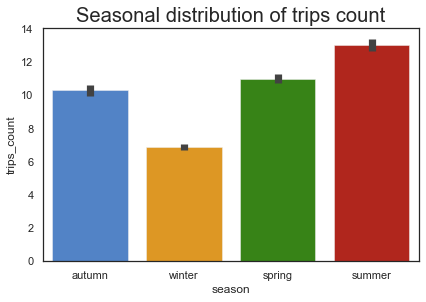

In [21]:
fig,ax = plt.subplots()
# plt.style.use('fivethirtyeight')
# sns.set_theme(style='white')
sns.barplot(data=df[["season","trips_count"]],
              x="season", y="trips_count", ax=ax, 
              palette=['#3F80D9','#FC9F05','#309505','#C81105'])
ax.set(title="Seasonal distribution of trips count")

In [19]:
# convert season to number
s = {'autumn': 1, 'winter': 2, 'spring': 3, 'summer': 4}
df['season'] = [s[df.at[i, 'season']] for i in range(len(df))]

## Feature selection

In [20]:
df = data.groupby(['date','hour', 'geohash_origin']).aggregate({'name_day':lambda x:x.to_list()[0], 'leisure':['sum'], 'public_services':['sum'], 'building':['sum'], 
            'education':['sum'], 'food':['sum'], 'transport':['sum'], 'finantial':['sum'], 'healthcare':['sum'], 'office':['sum'], 'shop':['sum'], 'tourism':['sum'], 
            'totalSnow_cm':['mean'], 'FeelsLikeC':['mean'], 'windspeedKmph':['mean'], 'tempC':['mean'], 'visibility':['mean'], 'precipMM':['mean'], 'count_bus_multimodality':['mean'], 
            'holiday':lambda x:x.to_list()[0], 'unique_id':['count']}).reset_index()
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)
df.trips_count.max(), df.trips_count.mean(), df.trips_count.median()

(18, 1.7191307344564049, 1.0)

In [23]:
# convert geohash to numbers
dgh={}
i=0
for gh in df.geohash_origin.unique():
    dgh[gh] = i
    i=i+1
df['geohash_origin'] = [dgh[df.at[i, 'geohash_origin']] for i in range(len(df))]

In [24]:
# convert weekdays to number
df['name_day'] = [d[df.at[i, 'name_day']] for i in range(len(df))]

In [25]:
X = df.drop(['date', 'trips_count'], axis=1) # df.iloc[:, 1:21] # take all variables except target and date
y = df[['trips_count']] # df.iloc[:, -1] # target variable

## F-Statistic

In [26]:
# compute ANOVA f-value, return an array with f-statistic for each feature and 
# an array with p-values, each associated to the corresponding f-statistic
bestfeatures = f_classif(X, y)
bestfeatures

(array([1.36887248e+01, 4.86659282e+02, 2.85448931e+00, 2.60279619e+02,
        7.83917235e+01, 4.76314607e+02, 3.58893039e+02, 9.54310307e+02,
        1.27624458e+03, 1.15302300e+02, 5.43290103e+01, 2.10274083e+02,
        2.09177118e+03, 3.22077771e+02, 1.00689310e+00, 3.14316275e+01,
        8.68339897e+00, 3.28581570e+01, 2.25565335e+00, 5.68187698e-01,
        1.41373003e-01, 1.71293262e+00]),
 array([1.36448608e-037, 0.00000000e+000, 1.09982538e-004, 0.00000000e+000,
        7.13684903e-254, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 4.02639052e-173, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 4.45314112e-001, 2.69815678e-096,
        1.26050228e-021, 4.55997161e-101, 2.81821983e-003, 9.09599464e-001,
        9.99975521e-001, 3.72134093e-002]))

In [27]:
# compute f-critical value to evaluate the above result 
degree_freedom_nom = len(X.columns) - 1 # k -1 
degree_freedom_denom = len(X) - len(X.columns) # N - k
f.ppf(0.05, degree_freedom_nom, degree_freedom_denom) # takes: significance level, numerator degrees of freedom, denominator degree of freedom

0.55192545319565

In [28]:
for val in range(len(bestfeatures[0])):
    if bestfeatures[0][val] > f.ppf(0.05, degree_freedom_nom, degree_freedom_denom) and bestfeatures[1][val] < 0.05:
        print(df.columns[val+1], bestfeatures[0][val])

hour 13.688724757295198
geohash_origin 486.6592821168626
name_day 2.85448930912552
leisure 260.27961857673796
public_services 78.39172348740955
building 476.31460699630804
education 358.8930394180798
food 954.3103069190392
transport 1276.2445771173425
finantial 115.30229956805405
healthcare 54.32901033206211
office 210.27408290377355
shop 2091.7711802915924
tourism 322.07777095524585
FeelsLikeC 31.43162745249959
windspeedKmph 8.68339897403337
tempC 32.85815698744606
visibility 2.255653347384376
holiday 1.7129326224760386


In [29]:
pd.DataFrame({'f_statistic': bestfeatures[0], 'variable': df.columns.drop(['trips_count', 'date'])}).sort_values(by=['f_statistic'], ascending=False)

,f_statistic,variable
12,2091.771180,shop
8,1276.244577,transport
7,954.310307,food
1,486.659282,geohash_origin
5,476.314607,building
6,358.893039,education
13,322.077771,tourism
3,260.279619,leisure
11,210.274083,office
9,115.302300,finantial


Reproduce again the f-statistic using different sklearn method, just as check

In [30]:
bestfeatures = SelectKBest(score_func=f_classif, k=10)
fit = bestfeatures.fit(X, y)

In [31]:
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores],axis=1)
featureScores.columns = ['Variables', 'Scores']  # naming the dataframe columns
featureScores.sort_values(by=['Scores'], ascending=False)

,Variables,Scores
12,shop,2091.771180
8,transport,1276.244577
7,food,954.310307
1,geohash_origin,486.659282
5,building,476.314607
6,education,358.893039
13,tourism,322.077771
3,leisure,260.279619
11,office,210.274083
9,finantial,115.302300


## Mutual Information

In [32]:
# Compute mutual information: the mutual information between two random variables 
# is a non-negative value, which measures the dependency between the variables. 
# It is equal to zero if and only if two random variables are independent, 
# and higher values mean higher dependency. It can be used for univariate features selection.
mi = mutual_info_classif(X, y, random_state=404)
mi

array([0.00899703, 0.1559307 , 0.00189922, 0.02672658, 0.01153807,
       0.03939361, 0.03969085, 0.07846734, 0.13440495, 0.01774256,
       0.00756047, 0.02530321, 0.13230399, 0.02566567, 0.00211931,
       0.00719595, 0.0061271 , 0.00279225, 0.00887364, 0.00350421,
       0.02328228, 0.        ])

In [33]:
# print variables with highest mutual information
var=[]
for i in range(len(mi)):
    if mi[i] > 0.05:
        print(df.columns.drop(['trips_count', 'date'])[i], mi[i]) 
        var.append(df.columns.drop(['trips_count', 'date'])[i])

geohash_origin 0.1559306996391323
food 0.07846733844365095
transport 0.13440494682088056
shop 0.13230398655864728


In [34]:
print('The presence of', var[1:4], 'among the most important predictor factors confirm the trips purpose analysis, saying these are the most relevant trip purposes of people using e-scooters, but also the most relevant points of departure, as it is implied here.')

The presence of ['food', 'transport', 'shop'] among the most important predictor factors confirm the trips purpose analysis, saying these are the most relevant trip purposes of people using e-scooters, but also the most relevant points of departure, as it is implied here.


In [35]:
featureMI = pd.DataFrame({'MutualInformation': mi, 'variable': X.columns})
print(featureMI.nlargest(10,'MutualInformation')) # the 10 variables with highest MI

    MutualInformation                 variable
1            0.155931           geohash_origin
8            0.134405                transport
12           0.132304                     shop
7            0.078467                     food
6            0.039691                education
5            0.039394                 building
3            0.026727                  leisure
13           0.025666                  tourism
11           0.025303                   office
20           0.023282  count_bus_multimodality


## Feature importance

In [36]:
# ExtraTreesClassifier class implements a meta estimator that fits a number of randomized decision trees (a.k.a. extra-trees) 
# on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.
model = ExtraTreesClassifier()
model.fit(X, y)

ExtraTreesClassifier()

In [37]:
print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers

[0.10188485 0.11988804 0.07757382 0.0183944  0.01060398 0.0234925
 0.02165632 0.04207588 0.10724344 0.01426432 0.0107671  0.01931064
 0.06496637 0.01579617 0.00680413 0.08528736 0.08783077 0.08426925
 0.03419509 0.03803613 0.01061554 0.0050439 ]


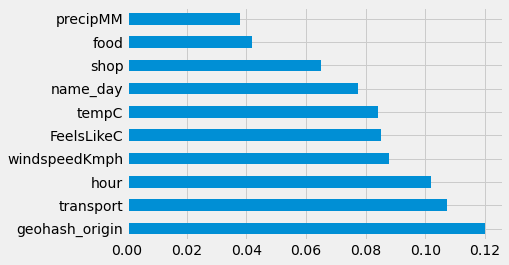

In [38]:
# plot graph of feature importances for better visualization
plt.style.use('fivethirtyeight')

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

## Correlation Matrix (Heatmap)

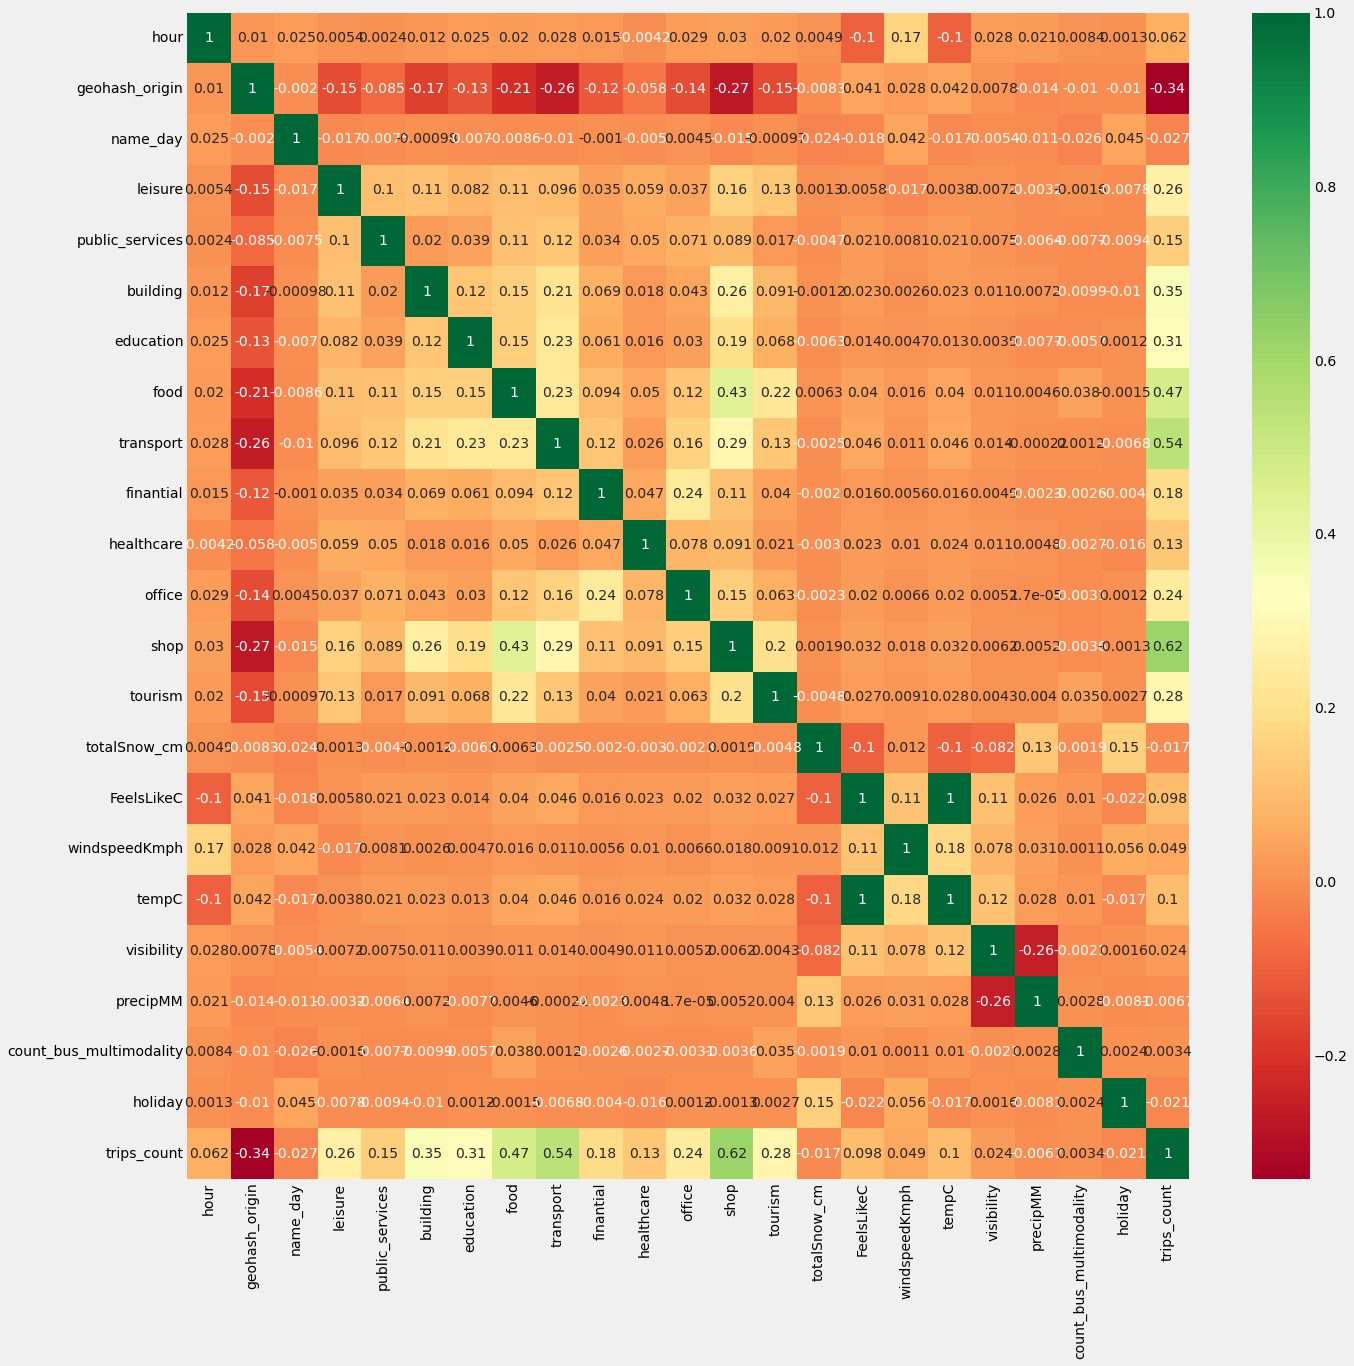

In [39]:
corrmat = df.corr() # correlation matrix
top_corr_features = corrmat.index
plt.figure(figsize=(20, 20))
g=sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn")

From the heatmap it is possible to observe that perceived temperature (FeelsLikeC) and real temperature (tempC) are correlated with 1 factor (perfect positive correlation), so we should remove either one or the other. We decided to remove FeelsLikeC, as previous analysis found tempC to be more impactful on the number of trips.

In [40]:
# correlation of each variable with the number of trips 
df.drop('trips_count', axis=1).corrwith(df.trips_count).sort_values(ascending=False)

shop                       0.619468
transport                  0.540204
food                       0.474878
building                   0.349987
education                  0.312115
tourism                    0.283249
leisure                    0.260738
office                     0.242774
finantial                  0.183633
public_services            0.149200
healthcare                 0.126267
tempC                      0.099785
FeelsLikeC                 0.097827
hour                       0.061543
windspeedKmph              0.048892
visibility                 0.024349
count_bus_multimodality    0.003380
precipMM                  -0.006681
totalSnow_cm              -0.016718
holiday                   -0.021124
name_day                  -0.027200
geohash_origin            -0.342779
dtype: float64

In [43]:
# ml_df = df.drop(["FeelsLikeC"], axis=1)
# ml_df.to_parquet('C:/Users/luisa/Desktop/thesis_project/data/ml_data.parquet')

In [45]:
data = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')
data = data.drop(["FeelsLikeC"], axis=1)
data.to_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')